Используемое устройство: cpu

Примеры изображений из датасета:


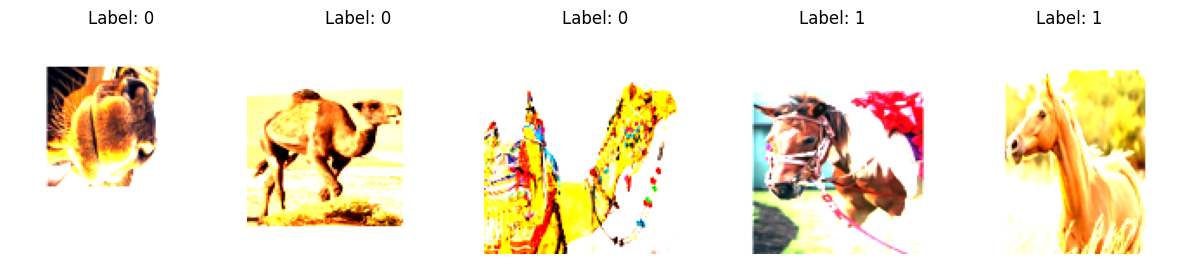


Общее количество обучаемых параметров: 8,408,386

Начало обучения...
Эпоха [1/5],  Батч [0/6], Loss: 0.7033

Эпоха [1/5] завершена -> | Среднее Loss: 5.2949, Точность: 0.4385
--------------------------------------------------
Эпоха [2/5],  Батч [0/6], Loss: 0.9369

Эпоха [2/5] завершена -> | Среднее Loss: 0.9659, Точность: 0.4646
--------------------------------------------------
Эпоха [3/5],  Батч [0/6], Loss: 0.6049

Эпоха [3/5] завершена -> | Среднее Loss: 0.6027, Точность: 0.6854
--------------------------------------------------
Эпоха [4/5],  Батч [0/6], Loss: 0.6655

Эпоха [4/5] завершена -> | Среднее Loss: 0.5820, Точность: 0.7094
--------------------------------------------------
Эпоха [5/5],  Батч [0/6], Loss: 0.5298

Эпоха [5/5] завершена -> | Среднее Loss: 0.5396, Точность: 0.7443
--------------------------------------------------
Обучение завершено.

Визуализация предсказаний на тестовой выборке:


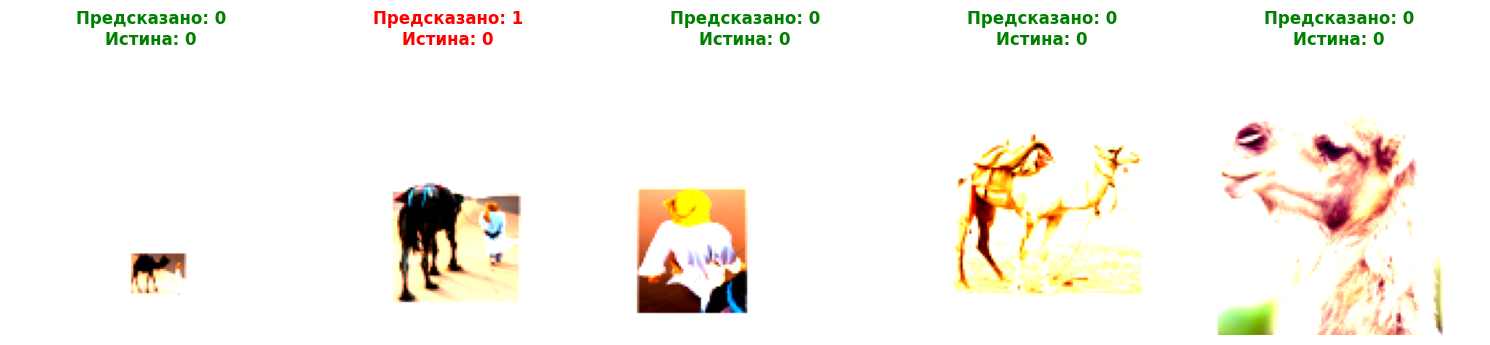


Результаты на тестовой выборке:
Средняя Loss: 0.6565
Точность: 0.7000 (28/40)


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

import shutil
from pathlib import Path


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Коллаб момент
root_path = Path('./data/a')

for p in Path(root_path).rglob(".ipynb_checkpoints"):
    shutil.rmtree(p)


train_dataset = datasets.ImageFolder('./drive/MyDrive/Colab Notebooks/archive/train/', transform=transform)
test_dataset = datasets.ImageFolder('./drive/MyDrive/Colab Notebooks/archive/test', transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

def show_samples(loader):
    dataiter = iter(loader)
    images, labels = next(dataiter)
    images = images

    fig, axes = plt.subplots(1, 5, figsize=(12, 5))
    for i in range(5):
        ax = axes[i % 5]
        ax.imshow(images[i].permute(1, 2, 0).squeeze())
        ax.set_title(f'Label: {labels[i].item()}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    return images, labels

print("\nПримеры изображений из датасета:")
images, labels = show_samples(train_loader)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 2)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = x.view(-1, 64 * 32 * 32)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nОбщее количество обучаемых параметров: {count_parameters(model):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total

def train_model(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        running_loss = 0.0
        running_accuracy = 0.0
        total_batches = len(train_loader)

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_accuracy += calculate_accuracy(outputs, labels)

            if batch_idx % 100 == 0:
                print(f'Эпоха [{epoch+1}/{epochs}],  Батч [{batch_idx}/{total_batches}], Loss: {loss.item():.4f}')

        epoch_loss = running_loss / total_batches
        epoch_accuracy = running_accuracy / total_batches

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(f'\nЭпоха [{epoch+1}/{epochs}] завершена -> | Среднее Loss: {epoch_loss:.4f}, Точность: {epoch_accuracy:.4f}')
        print('-' * 50)

    return train_losses, train_accuracies

print("\nНачало обучения...")
train_losses, train_accuracies = train_model(model, train_loader, criterion, optimizer, epochs=5)
print("Обучение завершено.")

def visualize_predictions(model, test_loader, num_images=10):
    model.eval()
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    images_subset = images[:num_images].to(device)
    labels_subset = labels[:num_images].to(device)

    with torch.no_grad():
        outputs = model(images_subset)
        _, predictions = torch.max(outputs, 1)

    images_cpu = images_subset.cpu()
    predictions_cpu = predictions.cpu()
    labels_cpu = labels_subset.cpu()

    fig, axes = plt.subplots(1, 5, figsize=(15, 6))
    for i in range(5):
        ax = axes[i % 5]
        ax.imshow(images_cpu[i].permute(1, 2, 0).squeeze(), cmap='gray')

        color = 'green' if predictions_cpu[i] == labels_cpu[i] else 'red'
        ax.set_title(f'Предсказано: {predictions_cpu[i].item()}\nИстина: {labels_cpu[i].item()}', color=color, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    return images_cpu, predictions_cpu, labels_cpu

print("\nВизуализация предсказаний на тестовой выборке:")
test_images, test_predictions, test_labels = visualize_predictions(model, test_loader, num_images=5)

def test_model(model, test_loader):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    avg_loss = test_loss / len(test_loader)

    print(f'\nРезультаты на тестовой выборке:')
    print(f'Средняя Loss: {avg_loss:.4f}')
    print(f'Точность: {accuracy:.4f} ({correct}/{total})')
    return accuracy

test_accuracy = test_model(model, test_loader)